In [13]:
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
    SwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path
from monodromy.haar import expected_cost

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

In [14]:
from gulps.utils.logging_config import logger

# logger.setLevel("INFO")
logger.setLevel("DEBUG")

In [18]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

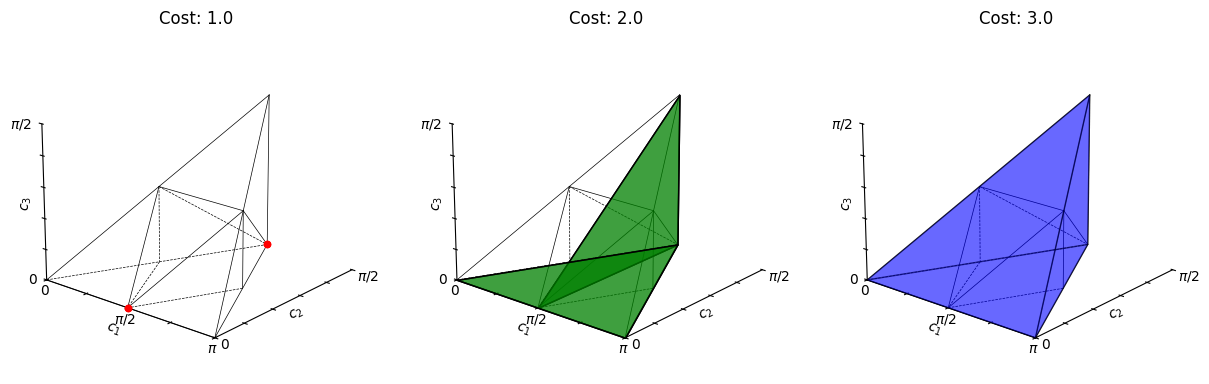

3.000000000000001


In [19]:
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_cost(decomposer.isa.coverage_set))

In [21]:
u = random_unitary(4, seed=1)
v = Operator(decomposer(u))
fid = average_gate_fidelity(u, v)

[gulps.local_numerics] DEBUG: [EASY 1/4] residual=[ 1.75692794e-14  2.39426358e-17 -4.55191440e-15] (‖residual‖=1.65e-28, nfev=23)
[gulps.local_numerics] DEBUG: => Success on [EASY 1] (componentwise |residual| ≤ 1.0e-08)
[gulps.local_numerics] DEBUG: ✅ LM synthesis SUCCESS on EASY attempt 1 (residual=1.65e-28, total_nfev=23) in 0.006s
[gulps.local_numerics] DEBUG: constructedqiskit convention: 0.7853981633974482, 0.40559562565723084, -0.27385846738101627
[gulps.local_numerics] DEBUG: target qiskit convention: 0.7853981633974483, 0.4055956256572679, 0.2738584673809764
[gulps.local_numerics] DEBUG: Segment 1 constructed invariant: [-1.42576013e-01 -6.86580100e-18 -5.93902552e-01] (target: [-0.14257601335544492, 2.3526323799013897e-17, -0.5939025515177657])
[gulps.local_numerics] DEBUG: Segment 1 constructed monodromy: (np.float64(0.4662769550221153), np.float64(0.0337230449778847), np.float64(-0.20806676014292227)) (target: (np.float64(0.4662769550221143), np.float64(0.0337230449778857),

ValueError: Cannot recover local equivalence; Weyl differences [1.11022302e-16 3.70814490e-14 5.47716935e-01]

In [20]:
N = 10_000
fidelities = []

for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)

    if fid < 1 - 1e-6:
        print(f"Unitary {idx} fidelity is low: {fid:.8f}")
        print("Canonical invariants:")
        print("U:", c1c2c3(u))
        print("V:", c1c2c3(v))
        print("\n")
        continue

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities)}")
print(f"  Mean fidelity:   {np.mean(fidelities)}")
print(f"  Minimum fidelity:{np.min(fidelities)}")

  0%|          | 0/10000 [00:00<?, ?it/s][gulps.local_numerics] DEBUG: [EASY 1/4] residual=[-2.77555756e-17  3.11291919e-17 -1.11022302e-16] (‖residual‖=7.03e-33, nfev=5)
[gulps.local_numerics] DEBUG: => Success on [EASY 1] (componentwise |residual| ≤ 1.0e-08)


[gulps.local_numerics] DEBUG: ✅ LM synthesis SUCCESS on EASY attempt 1 (residual=7.03e-33, total_nfev=5) in 0.006s
[gulps.local_numerics] DEBUG: constructedqiskit convention: 0.7853981633974483, 0.5324215980021358, 0.17178396442999244
[gulps.local_numerics] DEBUG: target qiskit convention: 0.7853981633974483, 0.5324215980021356, 0.17178396442999244
[gulps.local_numerics] DEBUG: Segment 1 constructed invariant: [-8.68161884e-02 -5.52859862e-19 -7.57179491e-01] (target: [-0.08681618836029792, 3.081393110064629e-17, -0.7571794908169648])
[gulps.local_numerics] DEBUG: Segment 1 constructed monodromy: (np.float64(0.3647945240959406), np.float64(0.13520547590405924), np.float64(-0.025844407572236834)) (target: (np.float64(0.47415559242776295), np.float64(0.02584440757223705), np.float64(-0.1352054759040595)))
[gulps.local_numerics] DEBUG: [EASY 1/4] residual=[-6.95277169e-15  1.19071419e-14 -1.49880108e-15] (‖residual‖=9.62e-29, nfev=88)
[gulps.local_numerics] DEBUG: => Success on [EASY 1] (

ValueError: Cannot recover local equivalence; Weyl differences [1.11022302e-16 3.70814490e-14 5.47716935e-01]